
# 轉移學習：自訂的輸入層及辨識層
### 修改自[『TRANSFER LEARNING FOR COMPUTER VISION TUTORIAL』](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)


## 載入套件

In [1]:
import copy
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn, optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, models, transforms

## 載入資料

In [2]:
# 訓練資料進行資料增補，驗證資料不需要
data_transforms = {
    'train': transforms.Compose(
        [
            transforms.RandomResizedCrop(224),  # 資料增補
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    ),
    'val': transforms.Compose(
        [
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    ),
}

# 使用 ImageFolder 可方便轉換為 dataset
data_dir = 'hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=4, shuffle=True, num_workers=4) for x in ['train', 'val']}

# 取得資料筆數
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

# 取得類別
class_names = image_datasets['train'].classes

In [3]:
dataset_sizes

{'train': 244, 'val': 153}

## 檢查 GPU

In [4]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 顯示資料增補的圖像

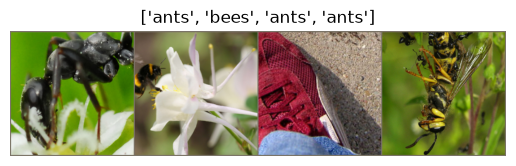

In [5]:
def imshow(inp: torch.Tensor, title: list[str] | str | None = None) -> None:
    inp_np = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp_np = std * inp_np + mean
    inp_np = np.clip(inp_np, 0, 1)
    plt.axis('off')
    plt.imshow(inp_np)
    if title is not None:
        plt.title(str(title))
    plt.pause(0.001)  # pause a bit so that plots are updated


# 取得一批資料
inputs, classes = next(iter(dataloaders['train']))

# 顯示一批資料
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

## 定義模型訓練函數

In [6]:
# 同時含訓練/評估
def train_model(
    model: nn.Module,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: lr_scheduler.LRScheduler,
    num_epochs: int = 25,
) -> nn.Module:
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()  # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = torch.tensor(0, device=device)

            # 逐批訓練或驗證
            inputs: torch.Tensor
            labels: torch.Tensor
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # 訓練時需要梯度下降
                with torch.set_grad_enabled(phase == 'train'):
                    outputs: torch.Tensor = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss: torch.Tensor = criterion(outputs, labels)

                    # 訓練時需要 backward + optimize
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # 統計損失
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.float() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # 如果是評估階段，且準確率創新高即存入 best_model_wts
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {(time_elapsed // 60):.0f}m {(time_elapsed % 60):.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # 載入最佳模型
    model.load_state_dict(best_model_wts)
    return model

## 定義顯示預測結果的函數

In [7]:
def imshow2(inp: torch.Tensor, title: str | None = None) -> None:
    inp_np = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp_np = std * inp_np + mean
    inp_np = np.clip(inp_np, 0, 1)
    plt.imshow(inp_np)

In [8]:
def visualize_model(model: nn.Module, num_images: int = 6) -> None:
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        inputs: torch.Tensor
        labels: torch.Tensor
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs: torch.Tensor = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                plt.subplot(num_images // 4 + 1, 4, images_so_far)
                plt.axis('off')
                plt.title(class_names[preds[j]])
                imshow2(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)
    plt.tight_layout()
    plt.show()

## 自訂辨識層

In [9]:
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model_ft.fc.in_features
# 改為自訂辨識層
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

# 定義損失函數
criterion = nn.CrossEntropyLoss()

# 定義優化器
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# 每7個執行週期，學習率降 0.1
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [10]:
model_ft.modules

<bound method Module.modules of ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

## 訓練：CPU訓練時間約需15~20分鐘

In [11]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.6334 Acc: 0.6844
val Loss: 0.2980 Acc: 0.8627

Epoch 1/24
----------
train Loss: 0.4497 Acc: 0.7787
val Loss: 0.2320 Acc: 0.9281

Epoch 2/24
----------
train Loss: 0.4532 Acc: 0.8074
val Loss: 0.3168 Acc: 0.9085

Epoch 3/24
----------
train Loss: 0.6508 Acc: 0.7828
val Loss: 0.6768 Acc: 0.8170

Epoch 4/24
----------
train Loss: 0.6932 Acc: 0.7746
val Loss: 0.3079 Acc: 0.8824

Epoch 5/24
----------
train Loss: 0.4780 Acc: 0.7623
val Loss: 0.3852 Acc: 0.8954

Epoch 6/24
----------
train Loss: 0.5410 Acc: 0.7992
val Loss: 0.3518 Acc: 0.8301

Epoch 7/24
----------
train Loss: 0.3894 Acc: 0.8320
val Loss: 0.2765 Acc: 0.8693

Epoch 8/24
----------
train Loss: 0.3917 Acc: 0.8361
val Loss: 0.2277 Acc: 0.9085

Epoch 9/24
----------
train Loss: 0.3294 Acc: 0.8484
val Loss: 0.2413 Acc: 0.9020

Epoch 10/24
----------
train Loss: 0.3269 Acc: 0.8689
val Loss: 0.2271 Acc: 0.8954

Epoch 11/24
----------
train Loss: 0.2591 Acc: 0.8893
val Loss: 0.2233 Acc: 0.9085

Ep

## 顯示預測結果

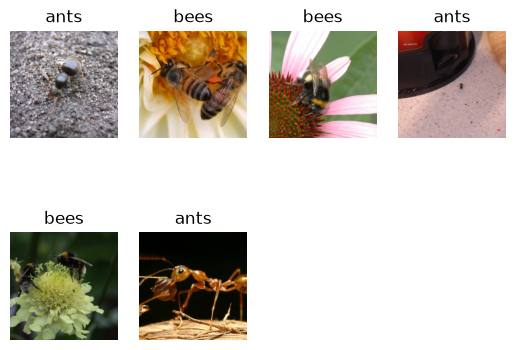

In [12]:
visualize_model(model_ft)

## 設定預先訓練的模型不用重新訓練，CPU訓練時間可以減半

In [13]:
model_conv = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model_conv.parameters():
    # 不用重新訓練
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

# 定義損失函數
criterion = nn.CrossEntropyLoss()

# 定義優化器
optimizer_conv = optim.SGD(model_conv.parameters(), lr=0.001, momentum=0.9)

# 每7個執行週期，學習率降 0.1
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

model_conv = train_model(model_conv, criterion, optimizer_conv, exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.6235 Acc: 0.6721
val Loss: 0.2648 Acc: 0.9085

Epoch 1/24
----------
train Loss: 0.4440 Acc: 0.8074
val Loss: 0.1898 Acc: 0.9412

Epoch 2/24
----------
train Loss: 0.3279 Acc: 0.8402
val Loss: 0.1944 Acc: 0.9281

Epoch 3/24
----------
train Loss: 0.4117 Acc: 0.8197
val Loss: 0.2096 Acc: 0.9346

Epoch 4/24
----------
train Loss: 0.4291 Acc: 0.8074
val Loss: 0.2113 Acc: 0.9412

Epoch 5/24
----------
train Loss: 0.4227 Acc: 0.8156
val Loss: 0.2231 Acc: 0.9216

Epoch 6/24
----------
train Loss: 0.3866 Acc: 0.8402
val Loss: 0.2069 Acc: 0.9281

Epoch 7/24
----------
train Loss: 0.3683 Acc: 0.8607
val Loss: 0.1749 Acc: 0.9412

Epoch 8/24
----------
train Loss: 0.3865 Acc: 0.8361
val Loss: 0.1768 Acc: 0.9477

Epoch 9/24
----------
train Loss: 0.3161 Acc: 0.8689
val Loss: 0.1739 Acc: 0.9477

Epoch 10/24
----------
train Loss: 0.3174 Acc: 0.8648
val Loss: 0.1873 Acc: 0.9412

Epoch 11/24
----------
train Loss: 0.3348 Acc: 0.8607
val Loss: 0.2030 Acc: 0.9412

Ep

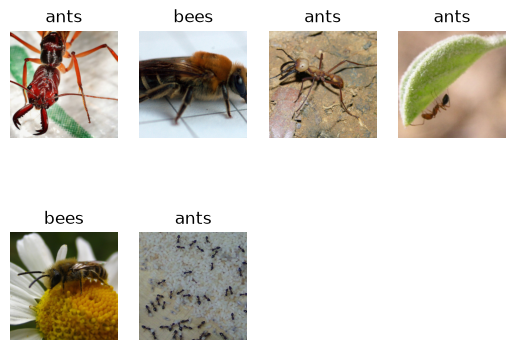

In [14]:
visualize_model(model_conv)

Further Learning
-----------------

If you would like to learn more about the applications of transfer learning,
checkout our `Quantized Transfer Learning for Computer Vision Tutorial <https://pytorch.org/tutorials/intermediate/quantized_transfer_learning_tutorial.html>`_.



